# Библиотеки

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## 7.8 IQR и выбросы\outliers

-  численность инженеров в функции обслуживания сети (столбец `'ШтЕд'`) в телеком-компании
- данные по количеству RBS (столбец `'RBS'`) базовых станций\телекоммуникационных вышек, которые эти инженеры сопровождают в каждом отделении.
- и это все в разрезе отделений компании (столбец `'Кодотделения'`).

In [2]:
k = pd.read_spss('./data/SPSS12.sav')

In [3]:
k['Нагрузка'] = k['RBS'] / k['ШтЕд']

In [4]:
Q3 = k['Нагрузка'].quantile(0.75)
Q1 = k['Нагрузка'].quantile(0.25)
IQR = Q3-Q1
UB = Q3+1.5*IQR
LB = Q1-1.5*IQR

k.loc[(k['Нагрузка'] < LB) | (k['Нагрузка'] > UB)]

,Кодотделения,RBS,ШтЕд,Нагрузка
6,S-7,987.0,12.0,82.25
23,N-1,402.0,4.0,100.50


## 7.9 Комлексный анализ описательных статистик: describe

In [5]:
g = k.describe().T

In [6]:
g['range'] = g['max']-g['min']
g['IQR'] = g['75%']-g['25%']
g['LB'] = g['25%']-1.5*g['IQR']
g['UB'] = g['75%']+1.5*g['IQR']

In [7]:
# g.loc['Нагрузка'] или g.iloc[2]
# g.loc[['Нагрузка']] или g.iloc[[2]]

In [8]:
k['FTEQ3'] = k['RBS'] / g.loc['Нагрузка', '75%']

In [9]:
k['ШтЕд_new'] = k['ШтЕд'].where(k['Нагрузка'] >= k['Нагрузка'].quantile(0.75), k['FTEQ3'].round())

In [10]:
k['Оптимизация'] = k['ШтЕд_new'] - k['ШтЕд']

In [11]:
Opt = k['Оптимизация'].sum()
OptPerc = Opt / k['ШтЕд'].sum()

<Axes: title={'center': 'Нагрузка'}, xlabel='Region'>

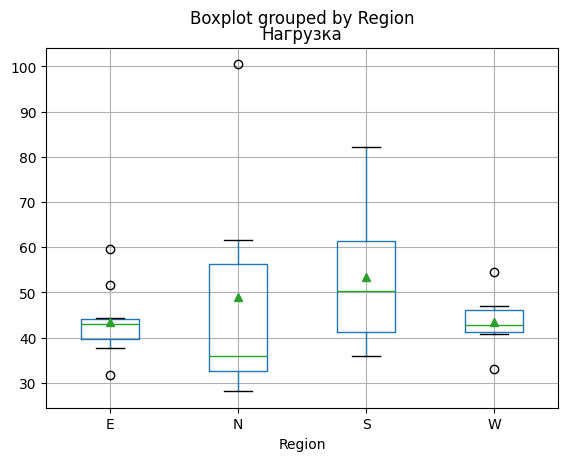

In [12]:
k[['Region', 'Branch']] = k['Кодотделения'].str.split("-", expand=True)

k.boxplot(column='Нагрузка', by='Region', showmeans=True)

# Визуализации данных

## 8.3 Агрегирующие и неагрегирующие диаграммы

array([[<Axes: title={'center': 'Нагрузка'}>]], dtype=object)

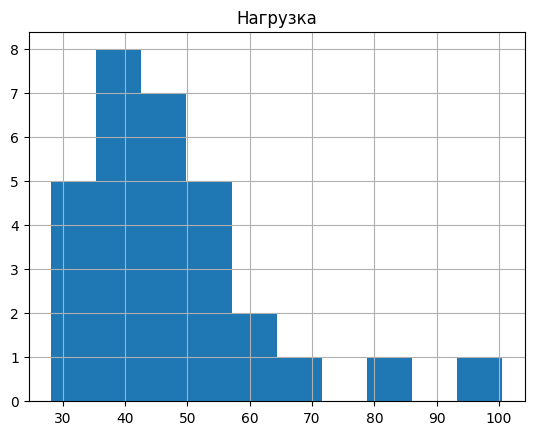

In [13]:
k.hist(column='Нагрузка')

array([[<Axes: title={'center': 'Нагрузка'}>]], dtype=object)

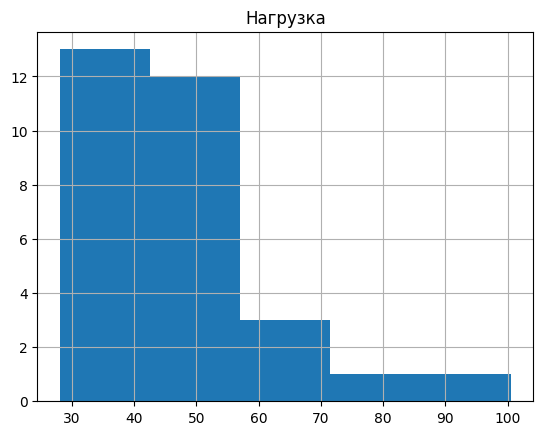

In [14]:
k.hist(column='Нагрузка', bins=5)

array([[<Axes: title={'center': 'E'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'W'}>]],
      dtype=object)

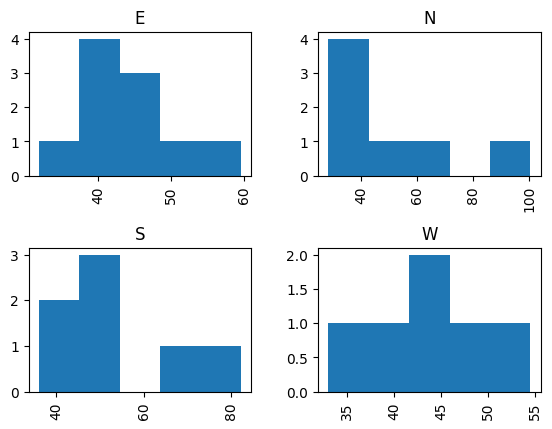

In [15]:
k.hist(column='Нагрузка', bins=5, by='Region')

array([[<Axes: title={'center': 'E'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'W'}>]],
      dtype=object)

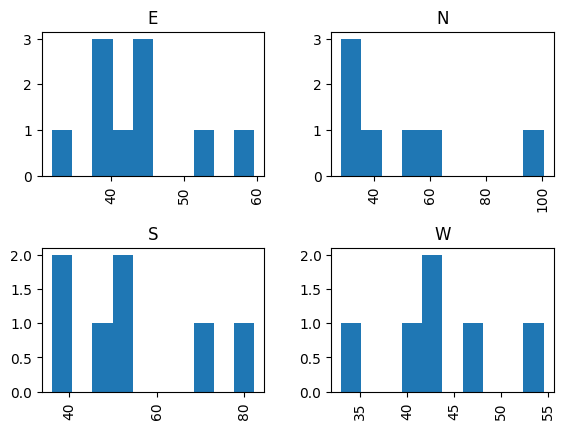

In [16]:
k.hist(column='Нагрузка', by='Region')

array([[<Axes: title={'center': 'E'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'W'}>]],
      dtype=object)

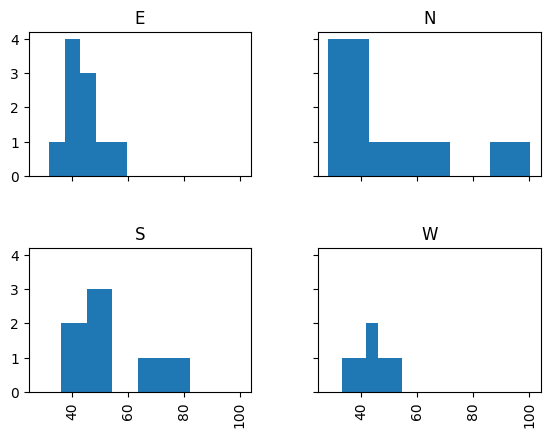

In [17]:
k.hist(column='Нагрузка', bins=5, by='Region',sharey=True, sharex=True)

array([[<Axes: title={'center': 'E'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'W'}>]],
      dtype=object)

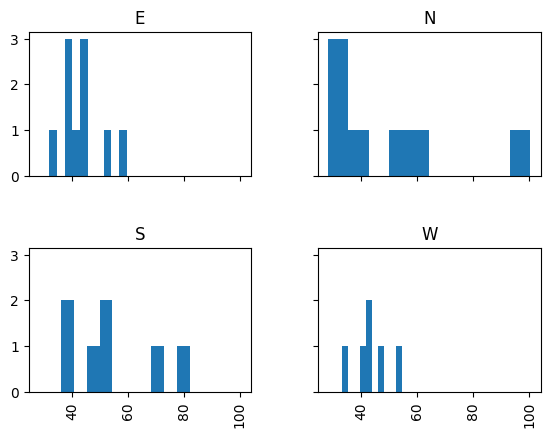

In [18]:
k.hist(column='Нагрузка', by='Region',sharey=True, sharex=True)

## 8.11 Погрешности\Коридор прогноза на диаграммах

In [19]:
u = k.groupby('Region')['Нагрузка'].agg(['mean', 'std'])

In [20]:
u

,mean,std
Region,,
E,43.396450,7.658315
N,48.930839,25.695845
S,53.410147,17.193732
W,43.497475,7.094174


<Axes: xlabel='Region'>

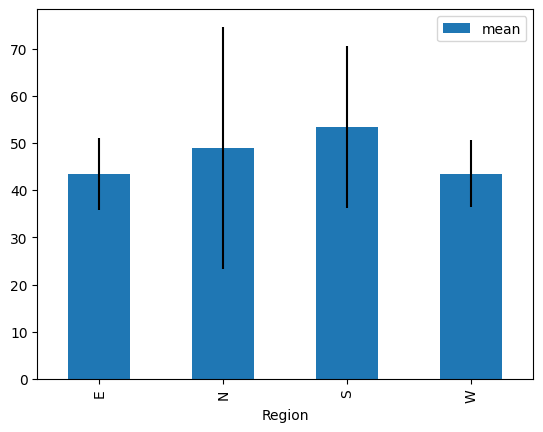

In [21]:
u.plot(kind='bar', y='mean', yerr='std')

## 8.13 Вторая Y-ось

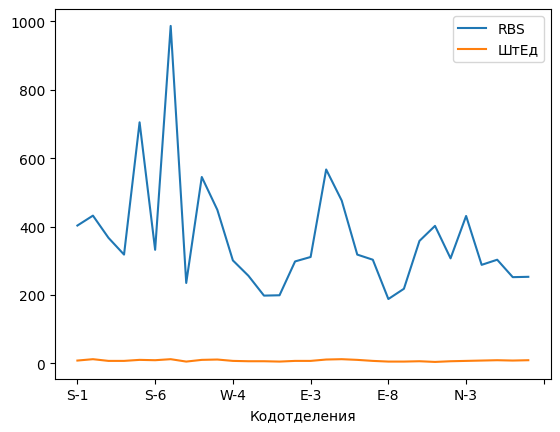

In [22]:
ax = k.plot.line(x='Кодотделения', y=['RBS', 'ШтЕд'])

[Text(0, 0, 'S-1'),
 Text(1, 0, 'S-2'),
 Text(2, 0, 'S-3'),
 Text(3, 0, 'S-4'),
 Text(4, 0, 'S-5'),
 Text(5, 0, 'S-6'),
 Text(6, 0, 'S-7'),
 Text(7, 0, 'W-1'),
 Text(8, 0, 'W-2'),
 Text(9, 0, 'W-3'),
 Text(10, 0, 'W-4'),
 Text(11, 0, 'W-5'),
 Text(12, 0, 'W-6'),
 Text(13, 0, 'E-1'),
 Text(14, 0, 'E-2'),
 Text(15, 0, 'E-3'),
 Text(16, 0, 'E-4'),
 Text(17, 0, 'E-5'),
 Text(18, 0, 'E-6'),
 Text(19, 0, 'E-7'),
 Text(20, 0, 'E-8'),
 Text(21, 0, 'E-9'),
 Text(22, 0, 'E-10'),
 Text(23, 0, 'N-1'),
 Text(24, 0, 'N-2'),
 Text(25, 0, 'N-3'),
 Text(26, 0, 'N-4'),
 Text(27, 0, 'N-5'),
 Text(28, 0, 'N-6'),
 Text(29, 0, 'N-7')]

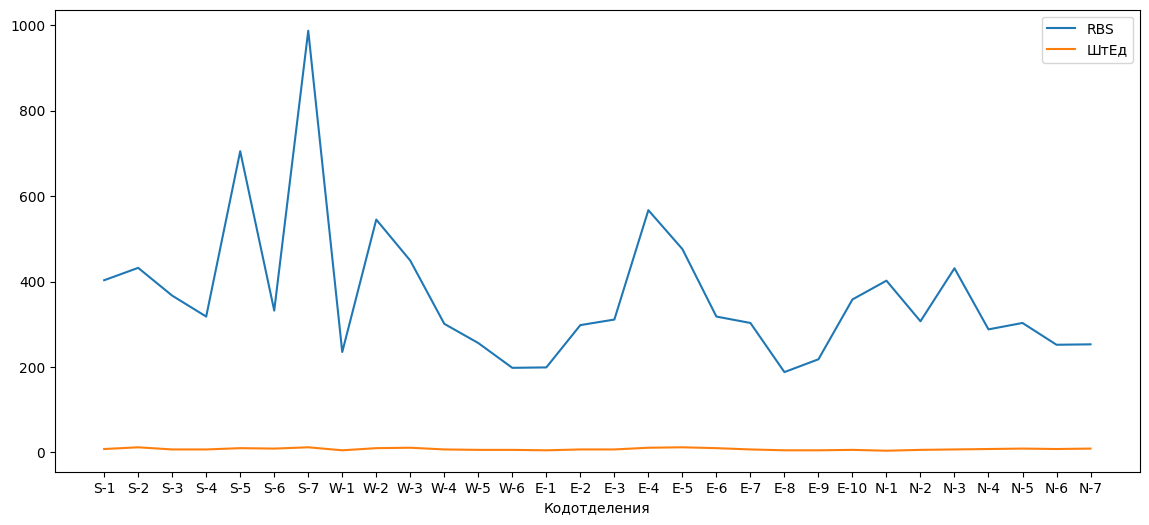

In [23]:
ax = k.plot.line(x='Кодотделения', y=['RBS', 'ШтЕд'], figsize=(14,6))
ax.set_xticks(range(len(k["Кодотделения"])))
ax.set_xticklabels(k["Кодотделения"])

[Text(0, 0, 'S-1'),
 Text(1, 0, 'S-2'),
 Text(2, 0, 'S-3'),
 Text(3, 0, 'S-4'),
 Text(4, 0, 'S-5'),
 Text(5, 0, 'S-6'),
 Text(6, 0, 'S-7'),
 Text(7, 0, 'W-1'),
 Text(8, 0, 'W-2'),
 Text(9, 0, 'W-3'),
 Text(10, 0, 'W-4'),
 Text(11, 0, 'W-5'),
 Text(12, 0, 'W-6'),
 Text(13, 0, 'E-1'),
 Text(14, 0, 'E-2'),
 Text(15, 0, 'E-3'),
 Text(16, 0, 'E-4'),
 Text(17, 0, 'E-5'),
 Text(18, 0, 'E-6'),
 Text(19, 0, 'E-7'),
 Text(20, 0, 'E-8'),
 Text(21, 0, 'E-9'),
 Text(22, 0, 'E-10'),
 Text(23, 0, 'N-1'),
 Text(24, 0, 'N-2'),
 Text(25, 0, 'N-3'),
 Text(26, 0, 'N-4'),
 Text(27, 0, 'N-5'),
 Text(28, 0, 'N-6'),
 Text(29, 0, 'N-7')]

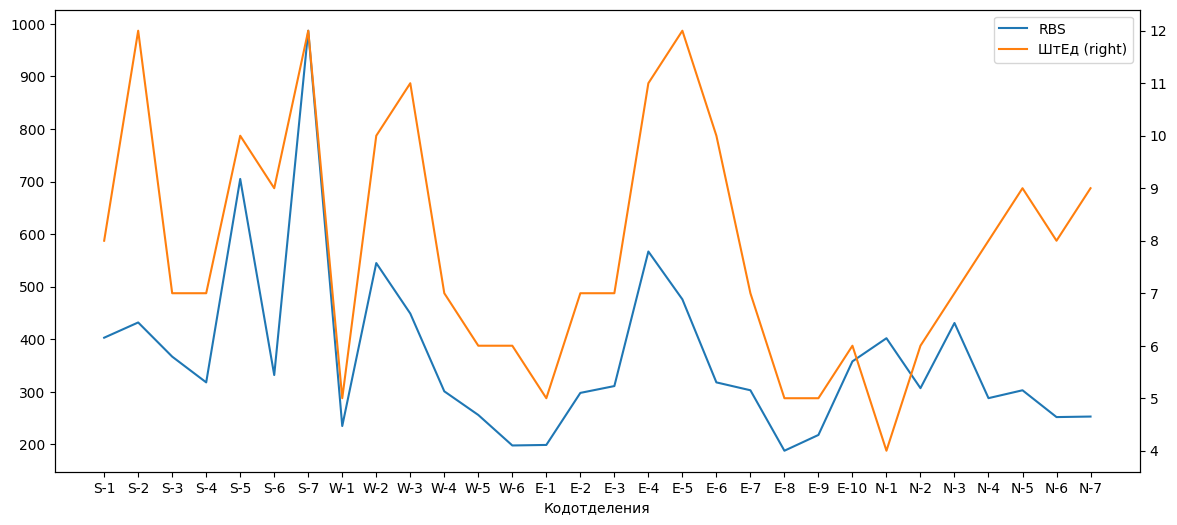

In [24]:
ax = k.plot.line(x='Кодотделения', y=['RBS', 'ШтЕд'], figsize=(14,6), secondary_y=['ШтЕд'])
ax.set_xticks(range(len(k["Кодотделения"])))
ax.set_xticklabels(k["Кодотделения"])

(0.0, 15.0)

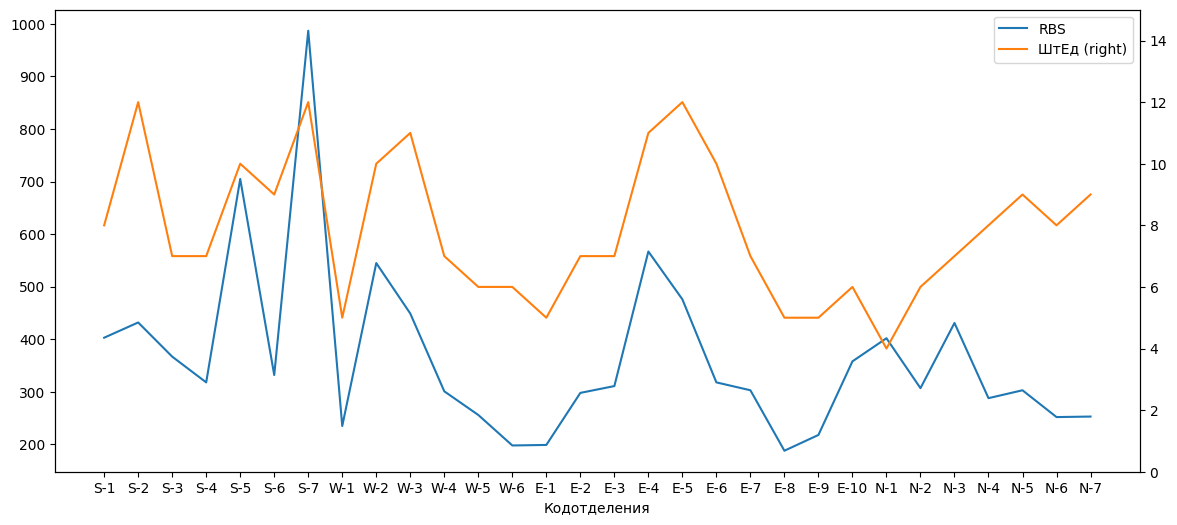

In [25]:
ax = k.plot.line(x='Кодотделения', y=['RBS', 'ШтЕд'], figsize=(14,6), secondary_y=['ШтЕд'], ylim=(0,1000))
ax.set_xticks(range(len(k["Кодотделения"])))
ax.set_xticklabels(k["Кодотделения"])
ax.right_ax.set_ylim(0,15)

## 8.14 Комбинированная диаграмма

<Axes: >

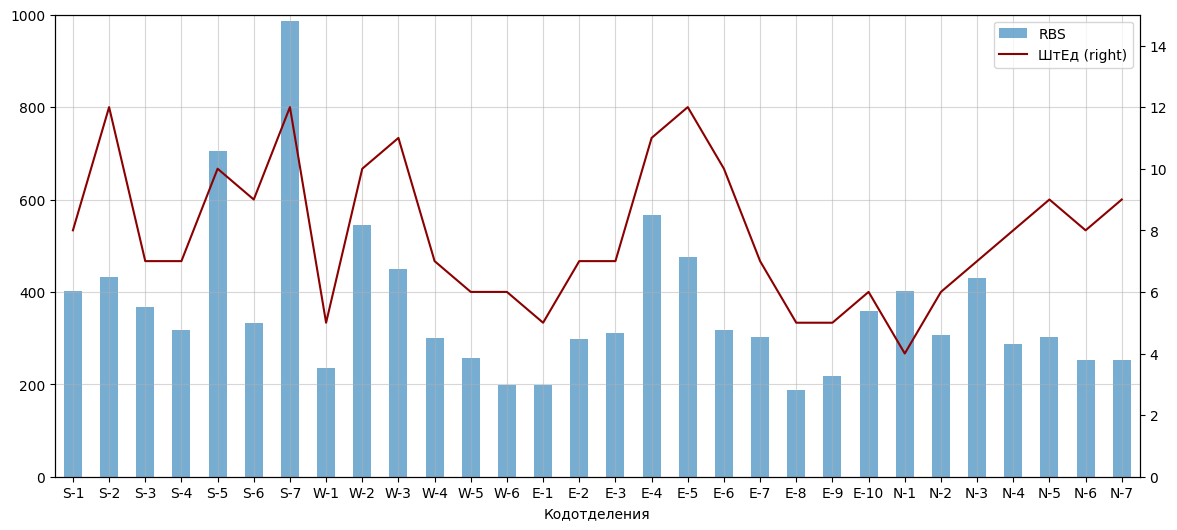

In [26]:
ax = k.plot.bar(x='Кодотделения', y=['RBS'], figsize=(14,6), ylim=(0,1000), alpha=.6)
ax.set_xticks(range(len(k["Кодотделения"])))
ax.grid(True, alpha=0.5)
ax.set_xticklabels(k["Кодотделения"])

k.plot.line(x='Кодотделения', y=['ШтЕд'], ax=ax, ylim=(0,15), secondary_y='ШтЕд', color='darkred')

## 8.21 Таблица - также визуальный элемент

In [32]:
(k[['Кодотделения','Нагрузка']]
    .style
        .format(precision=1)
        .format_index(str.upper,axis=1)
        .bar(color='blue')
        .highlight_quantile(q_right=0.75,props='color:red; font-weight:bold',subset='Нагрузка')
        .hide(subset=k[k['Нагрузка'] >= k['Нагрузка'].quantile(0.75)].index)
)

,КОДОТДЕЛЕНИЯ,НАГРУЗКА
0,S-1,50.4
1,S-2,36.0
3,S-4,45.4
5,S-6,36.9
7,W-1,47.0
9,W-3,40.8
10,W-4,43.0
11,W-5,42.7
12,W-6,33.0
13,E-1,39.8


# end